In [1]:
!pip install -U ultralytics sahi supervision opencv-python gdown


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
from google.colab import files

In [4]:

import datetime
import shutil

uploaded = files.upload()
image_filename = list(uploaded.keys())[0]

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

drive_image_path = f"/content/drive/MyDrive/inference_imgs/input_{timestamp}_{image_filename}"
output_image_name = f"prediction_{timestamp}_{image_filename.split('.')[0]}"
output_image_path = f"/content/drive/MyDrive/inference_imgs/{output_image_name}.png"

shutil.copy(image_filename, drive_image_path)

Saving UAVDT_05.jpg to UAVDT_05.jpg


'/content/drive/MyDrive/inference_imgs/input_20250801_134457_UAVDT_05.jpg'

In [5]:
from ultralytics import YOLOWorld
from sahi.predict import get_prediction, get_sliced_prediction, predict
from sahi import AutoDetectionModel
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
from collections import Counter

model_path = "/content/drive/MyDrive/yolov8s_worldv2/runs/weights/last.pt"
model = YOLOWorld(model_path)

detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model=model,
    confidence_threshold=0.25,
    device='cuda:0',
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
result = get_sliced_prediction(
    drive_image_path,
    detection_model,
    slice_height = 512,
    slice_width = 512,
    overlap_height_ratio = 0.2,
    overlap_width_ratio = 0.2

)



Performing prediction on 6 slices.


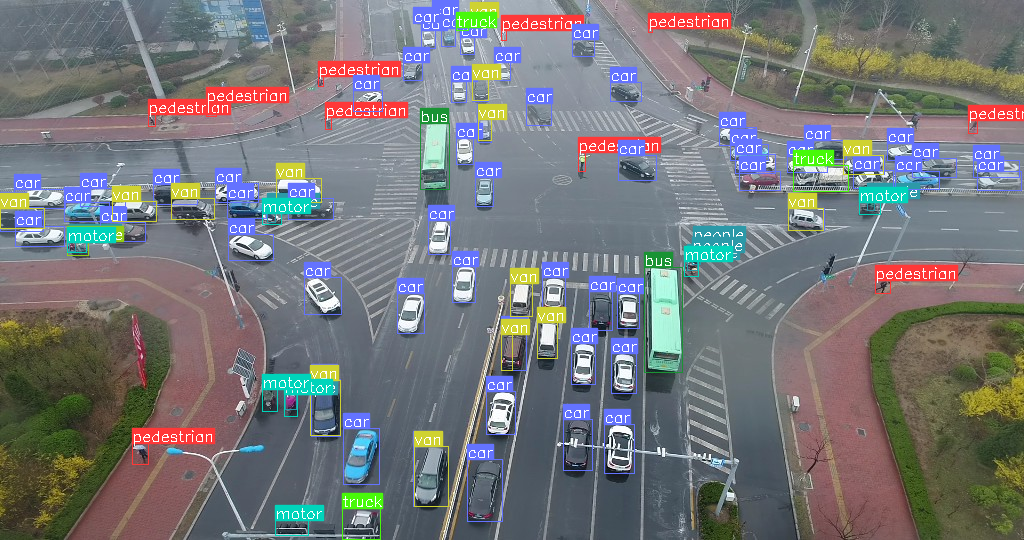


Detected Object Counts:
pedestrian: 10
people: 7
car: 61
van: 14
truck: 3
tricycle: 1
bus: 2
motor: 7


In [7]:
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
from collections import Counter

result.export_visuals(
    export_dir="/content/drive/MyDrive/inference_imgs/",
    text_size=0.5,  # Size of class label text
    rect_th=1,      # Thickness of bounding box lines
    hide_labels=False,
    hide_conf=True,
    file_name=output_image_name,

)

img = cv2.imread(output_image_path)
cv2_imshow(img)

class_names = [pred.category.name for pred in result.object_prediction_list]
class_counts = Counter(class_names)

print("\nDetected Object Counts:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")
